### data_train Description

This data_trainset, titled waze_data_trainset.csv, contains synthetic data_train created in partnership with Waze for the purpose of analyzing and predicting user churn. The data_trainset is designed to simulate real-world user behavior within the Waze app, allowing for the development and testing of machine learning models to understand user engagement and retention.
The data_trainset is supplied as part of the Google Advanced data_train Analytics Professional Certificate program.

In [538]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from pathlib import Path
import joblib
%matplotlib inline

### Path Defining

In [539]:
notebook_path=Path('__file__').resolve().parent
ROOT=notebook_path.parent

PATH1=ROOT/'data'/'raw'/'train.csv'
PATH2=ROOT/'data'/'raw'/'test.csv'
PATH_TRAIN_PARSED=ROOT/'data'/'parsed'/'train.csv'
PATH_TEST_PARSED=ROOT/'data'/'parsed'/'test.csv'
PATH_TRAIN_LABEL_PARSED=ROOT/'data'/'parsed'/'train_label.csv'
PATH_TEST_LABEL_PARSED=ROOT/'data'/'parsed'/'test_label.csv'
TRAINED_MODELS_PATH=ROOT/'src'/'serving'/'trained_models'

### CSV Import and data_trainset Exploration

In [540]:
data_train = pd.read_csv(PATH1)
# data_test = pd.read_csv(PATH2)

data_train, data_test=train_test_split(data_train, test_size=0.1, random_state=42, stratify=data_train['churn_risk_score']) #stratify for maintaining similar train test class proportions

data_train

,customer_id,Name,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,...,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
6546,fffe43004900440035003400330038003000,Sharita Burch,26,M,YTKFTI5,Village,Premium Membership,2017-12-27,No,xxxxxxxx,...,264.23,12911.51,Error,780.760000,No,Yes,Yes,Solved,Too many ads,3
12205,fffe43004900440033003700310030003600,Bonny Vanepps,21,F,6Y4LIX5,City,Gold Membership,2017-12-03,?,CID1333,...,170.95,35906.34,19.0,703.830000,Yes,No,Yes,Solved in Follow-up,Poor Product Quality,-1
20846,fffe43004900440032003700360031003100,Melinda Goold,44,F,HQX9U14,Town,Basic Membership,2017-08-23,?,CID51595,...,38.96,19201.85,Error,219.859326,Yes,No,Yes,Solved,Poor Customer Service,4
6211,fffe43004900440035003600340036003600,Kyla Goetsch,13,M,WBH99ZG,Town,Gold Membership,2015-11-02,No,xxxxxxxx,...,482.90,15388.76,23.0,620.180000,No,Yes,Yes,Solved in Follow-up,Poor Customer Service,4
27357,fffe43004900440033003000390031003100,Stephane Nipper,48,M,D035DRK,Village,Premium Membership,2015-11-11,Yes,CID35239,...,605.93,56745.18,14.0,784.900000,Yes,Yes,No,Not Applicable,Reasonable Price,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18377,fffe43004900440035003100350030003500,Luanna Cardwell,54,M,99I0S21,City,No Membership,2015-12-15,No,xxxxxxxx,...,171.59,40929.71,21.0,701.810000,No,Yes,Yes,Solved in Follow-up,Too many ads,4
22125,fffe43004900440035003200380036003800,Samantha Finnerty,11,M,2G53QPB,Town,Basic Membership,2017-05-22,Yes,CID44928,...,33.34,19559.29,6.0,622.130000,Yes,No,Yes,Unsolved,Poor Product Quality,4
16292,fffe43004900440032003600380034003100,Antonio Lenhardt,59,M,S0ZY13K,City,Premium Membership,2015-01-12,Yes,CID42077,...,658.61,49283.43,14.0,799.750000,Yes,No,No,Not Applicable,Too many ads,3
26539,fffe43004900440035003400320034003200,Nikki Pfarr,57,M,O6FWOI8,City,No Membership,2016-11-27,No,xxxxxxxx,...,265.52,44835.08,15.0,NaN,Yes,No,Yes,Solved,Too many ads,5


In [541]:
data_train['medium_of_operation'].unique()

<StringArray>
['?', 'Smartphone', 'Both', 'Desktop']
Length: 4, dtype: str

In [542]:
data_train.columns

Index(['customer_id', 'Name', 'age', 'gender', 'security_no',
       'region_category', 'membership_category', 'joining_date',
       'joined_through_referral', 'referral_id', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'last_visit_time',
       'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='str')

In [543]:
data_train.info()     # For getting a summary of the data_train (Gives details about existence of null data_train inside an attribute, useful)

<class 'pandas.DataFrame'>
Index: 26633 entries, 6546 to 21693
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   26633 non-null  str    
 1   Name                          26633 non-null  str    
 2   age                           26633 non-null  int64  
 3   gender                        26633 non-null  str    
 4   security_no                   26633 non-null  str    
 5   region_category               22680 non-null  str    
 6   membership_category           26633 non-null  str    
 7   joining_date                  26633 non-null  str    
 8   joined_through_referral       26633 non-null  str    
 9   referral_id                   26633 non-null  str    
 10  preferred_offer_types         26430 non-null  str    
 11  medium_of_operation           26633 non-null  str    
 12  internet_option               26633 non-null  str    
 13  last_visit_tim

In [544]:
data_train.describe()    # For getting descriptive statistical metrics for each column (only for non-string features)

,age,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,churn_risk_score
count,26633.000000,26633.000000,26633.000000,26633.000000,24185.000000,26633.000000
mean,37.095596,-42.164082,243.046775,29300.600147,687.635489,3.460256
std,15.894604,229.331211,401.595168,19476.326493,196.160640,1.409642
min,10.000000,-999.000000,-2814.109110,800.460000,-760.661236,-1.000000
25%,23.000000,8.000000,60.230000,14126.310000,616.620000,3.000000
50%,37.000000,12.000000,161.070000,27568.310000,698.100000,4.000000
75%,51.000000,16.000000,356.680000,40977.250000,764.600000,5.000000
max,64.000000,26.000000,3040.410000,99914.050000,2069.069761,5.000000


### Dropping unnecessary columns and Renaming column for clarity

In [545]:
data_train=data_train.drop(labels=['customer_id', 'Name', 'security_no', 'referral_id', 'last_visit_time'], axis=1)
data_train=data_train.rename(columns={'avg_time_spent':'avg_time_spent_in_seconds'})

data_test=data_test.drop(labels=['customer_id', 'Name', 'security_no', 'referral_id', 'last_visit_time'], axis=1)
data_test=data_test.rename(columns={'avg_time_spent':'avg_time_spent_in_seconds'})

data_train.T

,6546,12205,20846,6211,27357,2016,19206,17916,5496,19585,...,12350,7000,8794,14723,13186,18377,22125,16292,26539,21693
age,26,21,44,13,48,49,42,13,49,41,...,60,23,43,33,57,54,11,59,57,25
gender,M,F,F,M,M,F,M,F,F,F,...,M,M,F,M,M,M,M,M,M,M
region_category,Village,City,Town,Town,Village,City,NaN,NaN,Town,City,...,Town,NaN,Town,City,City,City,Town,City,City,City
membership_category,Premium Membership,Gold Membership,Basic Membership,Gold Membership,Premium Membership,Platinum Membership,Silver Membership,Basic Membership,Basic Membership,No Membership,...,Basic Membership,Basic Membership,Premium Membership,No Membership,Basic Membership,No Membership,Basic Membership,Premium Membership,No Membership,Platinum Membership
joining_date,2017-12-27,2017-12-03,2017-08-23,2015-11-02,2015-11-11,2016-03-09,2015-09-23,2017-06-06,2017-06-07,2015-03-09,...,2017-04-24,2016-08-04,2017-08-27,2017-05-27,2017-12-06,2015-12-15,2017-05-22,2015-01-12,2016-11-27,2016-02-23
joined_through_referral,No,?,?,No,Yes,?,Yes,No,?,Yes,...,Yes,No,No,No,No,No,Yes,Yes,No,Yes
preferred_offer_types,Gift Vouchers/Coupons,Without Offers,Without Offers,Credit/Debit Card Offers,Credit/Debit Card Offers,Gift Vouchers/Coupons,Credit/Debit Card Offers,Credit/Debit Card Offers,Gift Vouchers/Coupons,Credit/Debit Card Offers,...,Credit/Debit Card Offers,Without Offers,Credit/Debit Card Offers,Gift Vouchers/Coupons,Credit/Debit Card Offers,Credit/Debit Card Offers,Gift Vouchers/Coupons,Credit/Debit Card Offers,Credit/Debit Card Offers,Gift Vouchers/Coupons
medium_of_operation,?,Smartphone,?,?,?,Smartphone,?,Both,Both,Desktop,...,Desktop,Smartphone,Smartphone,Smartphone,?,Desktop,Smartphone,?,Desktop,Desktop
internet_option,Wi-Fi,Mobile_Data,Wi-Fi,Fiber_Optic,Fiber_Optic,Fiber_Optic,Mobile_Data,Mobile_Data,Fiber_Optic,Mobile_Data,...,Fiber_Optic,Wi-Fi,Fiber_Optic,Wi-Fi,Wi-Fi,Fiber_Optic,Fiber_Optic,Fiber_Optic,Mobile_Data,Wi-Fi
days_since_last_login,20,19,-999,8,14,12,11,21,15,9,...,8,9,20,21,17,23,16,11,6,4


In [546]:
data_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,26633.0,NaN,NaN,NaN,37.095596,15.894604,10.0,23.0,37.0,51.0,64.0
gender,26633,3,M,13304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_category,22680,3,Town,10180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_category,26633,6,Basic Membership,5547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
joining_date,26633,1096,2016-08-03,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
joined_through_referral,26633,3,No,11407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_offer_types,26430,3,Gift Vouchers/Coupons,8870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medium_of_operation,26633,4,Smartphone,10003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_option,26633,3,Wi-Fi,8938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_last_login,26633.0,NaN,NaN,NaN,-42.164082,229.331211,-999.0,8.0,12.0,16.0,26.0


In [547]:
# Checking for columns with possible redundant labels

data_train['feedback'].unique()  # only 9 and no missing values, so no need of dropping

<StringArray>
[            'Too many ads',     'Poor Product Quality',
    'Poor Customer Service',         'Reasonable Price',
      'No reason specified',    'Quality Customer Care',
    'User Friendly Website', 'Products always in Stock',
             'Poor Website']
Length: 9, dtype: str

In [548]:
data_train['complaint_status'].unique()   # only 5 and no missing values, so no need of dropping

<StringArray>
[                  'Solved',      'Solved in Follow-up',
           'Not Applicable',                 'Unsolved',
 'No Information Available']
Length: 5, dtype: str

### data_train Cleaning

### Fixing placeholder values

In [549]:
data_train['days_since_last_login']=data_train['days_since_last_login'].replace(-999,pd.NA)
data_train.loc[data_train['avg_time_spent_in_seconds']<0, 'avg_time_spent_in_seconds']=pd.NA
data_train.loc[data_train['points_in_wallet']<0, 'points_in_wallet']=pd.NA
data_train.loc[data_train['avg_frequency_login_days']=='Error', 'avg_frequency_login_days']=pd.NA
data_train.loc[data_train['churn_risk_score']<0, 'churn_risk_score']=pd.NA


data_test['days_since_last_login']=data_test['days_since_last_login'].replace(-999,pd.NA)
data_test.loc[data_test['avg_time_spent_in_seconds']<0, 'avg_time_spent_in_seconds']=pd.NA
data_test.loc[data_test['points_in_wallet']<0, 'points_in_wallet']=pd.NA
data_test.loc[data_test['avg_frequency_login_days']=='Error', 'avg_frequency_login_days']=pd.NA
data_test.loc[data_test['churn_risk_score']<0, 'churn_risk_score']=pd.NA


data_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,26633.0,NaN,NaN,NaN,37.095596,15.894604,10.0,23.0,37.0,51.0,64.0
gender,26633,3,M,13304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_category,22680,3,Town,10180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_category,26633,6,Basic Membership,5547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
joining_date,26633,1096,2016-08-03,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
joined_through_referral,26633,3,No,11407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_offer_types,26430,3,Gift Vouchers/Coupons,8870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medium_of_operation,26633,4,Smartphone,10003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_option,26633,3,Wi-Fi,8938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_last_login,25187.0,26.0,13.0,1705.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [550]:
data_train.columns

Index(['age', 'gender', 'region_category', 'membership_category',
       'joining_date', 'joined_through_referral', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'days_since_last_login',
       'avg_time_spent_in_seconds', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='str')

### Fixing data_train types before additional formatting

In [551]:
data_train.info()

<class 'pandas.DataFrame'>
Index: 26633 entries, 6546 to 21693
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           26633 non-null  int64  
 1   gender                        26633 non-null  str    
 2   region_category               22680 non-null  str    
 3   membership_category           26633 non-null  str    
 4   joining_date                  26633 non-null  str    
 5   joined_through_referral       26633 non-null  str    
 6   preferred_offer_types         26430 non-null  str    
 7   medium_of_operation           26633 non-null  str    
 8   internet_option               26633 non-null  str    
 9   days_since_last_login         25187 non-null  object 
 10  avg_time_spent_in_seconds     25371 non-null  float64
 11  avg_transaction_value         26633 non-null  float64
 12  avg_frequency_login_days      24130 non-null  str    
 13  points_in_wall

In [552]:
data_train['joining_date']=pd.to_datetime(data_train['joining_date'], errors='coerce')
data_train['avg_frequency_login_days']=pd.to_numeric(data_train['avg_frequency_login_days'], errors='coerce')
data_train['days_since_last_login']=pd.to_numeric(data_train['days_since_last_login'], errors='coerce')

data_train.loc[data_train['avg_frequency_login_days']<0, 'avg_frequency_login_days']=pd.NA


data_test['joining_date']=pd.to_datetime(data_test['joining_date'], errors='coerce')
data_test['avg_frequency_login_days']=pd.to_numeric(data_test['avg_frequency_login_days'], errors='coerce')
data_test['days_since_last_login']=pd.to_numeric(data_test['days_since_last_login'], errors='coerce')

data_test.loc[data_test['avg_frequency_login_days']<0, 'avg_frequency_login_days']=pd.NA


data_train.info()

<class 'pandas.DataFrame'>
Index: 26633 entries, 6546 to 21693
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   age                           26633 non-null  int64         
 1   gender                        26633 non-null  str           
 2   region_category               22680 non-null  str           
 3   membership_category           26633 non-null  str           
 4   joining_date                  26633 non-null  datetime64[us]
 5   joined_through_referral       26633 non-null  str           
 6   preferred_offer_types         26430 non-null  str           
 7   medium_of_operation           26633 non-null  str           
 8   internet_option               26633 non-null  str           
 9   days_since_last_login         25187 non-null  float64       
 10  avg_time_spent_in_seconds     25371 non-null  float64       
 11  avg_transaction_value         26633 non-n

### Removing metadata_train based columns by creating new columns with extracted relevant information

In [553]:
reference_date=pd.to_datetime('2021-04-01')

data_train['days_since_joined']=(reference_date - data_train['joining_date'])/pd.Timedelta(days=1)
data_train.drop(columns=['joining_date'], inplace=True)


data_test['days_since_joined']=(reference_date - data_test['joining_date'])/pd.Timedelta(days=1)
data_test.drop(columns=['joining_date'], inplace=True)


data_train.info()

<class 'pandas.DataFrame'>
Index: 26633 entries, 6546 to 21693
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           26633 non-null  int64  
 1   gender                        26633 non-null  str    
 2   region_category               22680 non-null  str    
 3   membership_category           26633 non-null  str    
 4   joined_through_referral       26633 non-null  str    
 5   preferred_offer_types         26430 non-null  str    
 6   medium_of_operation           26633 non-null  str    
 7   internet_option               26633 non-null  str    
 8   days_since_last_login         25187 non-null  float64
 9   avg_time_spent_in_seconds     25371 non-null  float64
 10  avg_transaction_value         26633 non-null  float64
 11  avg_frequency_login_days      23642 non-null  float64
 12  points_in_wallet              24086 non-null  float64
 13  used_special_d

In [554]:
data_train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,26633.0,NaN,NaN,NaN,37.095596,15.894604,10.0,23.0,37.0,51.0,64.0
gender,26633,3,M,13304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region_category,22680,3,Town,10180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_category,26633,6,Basic Membership,5547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
joined_through_referral,26633,3,No,11407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
preferred_offer_types,26430,3,Gift Vouchers/Coupons,8870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
medium_of_operation,26633,4,Smartphone,10003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_option,26633,3,Wi-Fi,8938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_last_login,25187.0,NaN,NaN,NaN,12.768412,5.580124,1.0,9.0,13.0,17.0,26.0
avg_time_spent_in_seconds,25371.0,NaN,NaN,NaN,293.577299,333.601563,1.837399,71.7,174.04,371.965,3040.41


In [555]:
data_train['feedback'].unique()

<StringArray>
[            'Too many ads',     'Poor Product Quality',
    'Poor Customer Service',         'Reasonable Price',
      'No reason specified',    'Quality Customer Care',
    'User Friendly Website', 'Products always in Stock',
             'Poor Website']
Length: 9, dtype: str

In [556]:
data_train.columns

Index(['age', 'gender', 'region_category', 'membership_category',
       'joined_through_referral', 'preferred_offer_types',
       'medium_of_operation', 'internet_option', 'days_since_last_login',
       'avg_time_spent_in_seconds', 'avg_transaction_value',
       'avg_frequency_login_days', 'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score', 'days_since_joined'],
      dtype='str')

### CCA (performed only on target column)

In [557]:
data_train.isnull().mean()*100   # None of the vases have very high percentage of data_train missing. So no need of removing any of the columns outright

age                              0.000000
gender                           0.000000
region_category                 14.842489
membership_category              0.000000
joined_through_referral          0.000000
preferred_offer_types            0.762212
medium_of_operation              0.000000
internet_option                  0.000000
days_since_last_login            5.429355
avg_time_spent_in_seconds        4.738482
avg_transaction_value            0.000000
avg_frequency_login_days        11.230428
points_in_wallet                 9.563324
used_special_discount            0.000000
offer_application_preference     0.000000
past_complaint                   0.000000
complaint_status                 0.000000
feedback                         0.000000
churn_risk_score                 3.131453
days_since_joined                0.000000
dtype: float64

In [558]:
# Pre churn risk score cca distribution of churn risk score variable
data_train_churn_risk=data_train['churn_risk_score']
data_train_old_churn_risk=data_train_churn_risk.copy()

In [559]:
# Dropping rows with all columns as na
data_train=data_train.dropna(how='all')
data_test=data_test.dropna(how='all')

In [560]:
# Dropping rows with missing churn risk score (Since its the target column and imputing it might introduce unnecessary noise and false assumptions)
# Dopping numericrows with ~5% missing data_train
print(len(data_train.dropna(subset=['churn_risk_score']))/len(data_train))
data_train=data_train.dropna(subset=['churn_risk_score'])
data_test=data_test.dropna(subset=['churn_risk_score'])

len(data_train)

0.9686854654000676


25799

### Feature Engineering

#### CCA validation check

<Axes: ylabel='Density'>

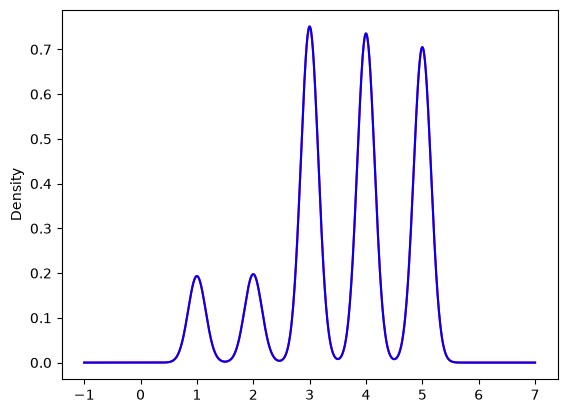

In [561]:
# Post churn risk score cca distribution of churn risk score variable
ax=data_train_old_churn_risk.plot.density(color='red')
data_train['churn_risk_score'].plot.density(ax=ax,color='blue')

# Density remains almost unchanged, so performing cca on churn risk was safe

### data_train Imputation

In [562]:
# Updated percentages
data_train.isnull().mean()*100

age                              0.000000
gender                           0.000000
region_category                 14.833908
membership_category              0.000000
joined_through_referral          0.000000
preferred_offer_types            0.748091
medium_of_operation              0.000000
internet_option                  0.000000
days_since_last_login            5.465328
avg_time_spent_in_seconds        4.713361
avg_transaction_value            0.000000
avg_frequency_login_days        11.236870
points_in_wallet                 9.593395
used_special_discount            0.000000
offer_application_preference     0.000000
past_complaint                   0.000000
complaint_status                 0.000000
feedback                         0.000000
churn_risk_score                 0.000000
days_since_joined                0.000000
dtype: float64

### Categorical

In [563]:
# First tackling preferred_offer_types with mode imputation since its missing percentage is very less

data_train_mode=data_train['preferred_offer_types'].mode()[0]
print(data_train_mode)

data_train['preferred_offer_types']=data_train['preferred_offer_types'].fillna(value=data_train_mode)
data_test['preferred_offer_types']=data_test['preferred_offer_types'].fillna(value=data_train_mode)

Gift Vouchers/Coupons


In [564]:
# Convert NA data_train in region_data_train_category to seperate unknown type (for now)

data_train['region_category']=data_train['region_category'].fillna(value='Unknown')
data_test['region_category']=data_test['region_category'].fillna(value='Unknown')


In [565]:
# Implementing MICE imputation on the remaning numeric columns

data_train_missing_num=data_train[['days_since_last_login', 
                      'avg_time_spent_in_seconds', 
                      'avg_frequency_login_days', 
                      'points_in_wallet']]

data_test_missing_num=data_test[['days_since_last_login', 
                      'avg_time_spent_in_seconds', 
                      'avg_frequency_login_days', 
                      'points_in_wallet']]

data_train_missing_num

,days_since_last_login,avg_time_spent_in_seconds,avg_frequency_login_days,points_in_wallet
6546,20.0,264.23,NaN,780.760000
20846,NaN,38.96,NaN,219.859326
6211,8.0,482.90,23.0,620.180000
27357,14.0,605.93,14.0,784.900000
2016,12.0,295.05,5.0,732.920000
...,...,...,...,...
18377,23.0,171.59,21.0,701.810000
22125,16.0,33.34,6.0,622.130000
16292,11.0,658.61,14.0,799.750000
26539,6.0,265.52,15.0,NaN


In [566]:
imputer=IterativeImputer(max_iter=5, random_state=6)
imputed_data_train=imputer.fit_transform(data_train_missing_num)
imputed_data_train

array([[ 20.        , 264.23      ,  16.33797295, 780.76      ],
       [ 13.24530419,  38.96      ,  17.70267368, 219.85932563],
       [  8.        , 482.9       ,  23.        , 620.18      ],
       ...,
       [ 11.        , 658.61      ,  14.        , 799.75      ],
       [  6.        , 265.52      ,  15.        , 693.21477947],
       [  4.        ,  56.89      ,  15.        , 755.18      ]],
      shape=(25799, 4))

In [567]:
output_data_train = pd.DataFrame(
    imputed_data_train,
    columns=data_train_missing_num.columns,
    index=data_train_missing_num.index
)

data_train[output_data_train.columns] = output_data_train

In [568]:
imputed_data_test=imputer.transform(data_test_missing_num)

output_data_test = pd.DataFrame(
    imputed_data_test,
    columns=data_test_missing_num.columns,
    index=data_test_missing_num.index
)

data_test[output_data_test.columns] = output_data_test

In [569]:
data_train.isna().mean()*100

age                             0.0
gender                          0.0
region_category                 0.0
membership_category             0.0
joined_through_referral         0.0
preferred_offer_types           0.0
medium_of_operation             0.0
internet_option                 0.0
days_since_last_login           0.0
avg_time_spent_in_seconds       0.0
avg_transaction_value           0.0
avg_frequency_login_days        0.0
points_in_wallet                0.0
used_special_discount           0.0
offer_application_preference    0.0
past_complaint                  0.0
complaint_status                0.0
feedback                        0.0
churn_risk_score                0.0
days_since_joined               0.0
dtype: float64

### Encoding of Categorical data

In [570]:
data_train.info()

<class 'pandas.DataFrame'>
Index: 25799 entries, 6546 to 21693
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   age                           25799 non-null  int64  
 1   gender                        25799 non-null  str    
 2   region_category               25799 non-null  str    
 3   membership_category           25799 non-null  str    
 4   joined_through_referral       25799 non-null  str    
 5   preferred_offer_types         25799 non-null  str    
 6   medium_of_operation           25799 non-null  str    
 7   internet_option               25799 non-null  str    
 8   days_since_last_login         25799 non-null  float64
 9   avg_time_spent_in_seconds     25799 non-null  float64
 10  avg_transaction_value         25799 non-null  float64
 11  avg_frequency_login_days      25799 non-null  float64
 12  points_in_wallet              25799 non-null  float64
 13  used_special_d

In [571]:
data_train.describe(include='all')

,age,gender,region_category,membership_category,joined_through_referral,preferred_offer_types,medium_of_operation,internet_option,days_since_last_login,avg_time_spent_in_seconds,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score,days_since_joined
count,25799.000000,25799,25799,25799,25799,25799,25799,25799,25799.000000,25799.000000,25799.000000,25799.000000,25799.000000,25799,25799,25799,25799,25799,25799.000000,25799.000000
unique,NaN,3,4,6,3,3,4,3,NaN,NaN,NaN,NaN,NaN,2,2,2,5,9,NaN,NaN
top,NaN,M,Town,Basic Membership,No,Gift Vouchers/Coupons,Smartphone,Wi-Fi,NaN,NaN,NaN,NaN,NaN,Yes,Yes,No,Not Applicable,Too many ads,NaN,NaN
freq,NaN,12915,9874,5364,11058,8795,9700,8652,NaN,NaN,NaN,NaN,NaN,14148,14247,12984,12984,4409,NaN,NaN
mean,37.096360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.760753,293.314455,29331.399286,16.554561,691.288489,NaN,NaN,NaN,NaN,NaN,3.604442,1730.871274
std,15.895175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.428993,325.211619,19510.735789,7.854394,179.395820,NaN,NaN,NaN,NaN,NaN,1.177883,318.331707
min,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.837399,800.460000,0.009208,6.432208,NaN,NaN,NaN,NaN,NaN,1.000000,1187.000000
25%,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,75.375000,14145.955000,11.000000,625.775000,NaN,NaN,NaN,NaN,NaN,3.000000,1454.000000
50%,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,186.490000,27607.460000,16.472123,694.520000,NaN,NaN,NaN,NaN,NaN,4.000000,1729.000000
75%,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.000000,359.084116,40992.290000,22.000000,757.680000,NaN,NaN,NaN,NaN,NaN,5.000000,2010.000000


In [572]:
# Implementing Ordinal encoding on the categorical columns

onehot_encoder=OneHotEncoder(sparse_output=False, drop='first')

nominal_columns=['gender', 
           'region_category',
           'membership_category', 
           'joined_through_referral', 
           'preferred_offer_types', 
           'medium_of_operation', 
           'internet_option', 
           'used_special_discount', 
           'offer_application_preference', 
           'past_complaint', 
           'complaint_status', 
           'feedback']


train_ohe = onehot_encoder.fit_transform(data_train[nominal_columns])
test_ohe = onehot_encoder.transform(data_test[nominal_columns])

joblib.dump(onehot_encoder, TRAINED_MODELS_PATH/'onehot_encoder.joblib')

nominal_headers=onehot_encoder.get_feature_names_out(nominal_columns)

train_ohe_df=pd.DataFrame(data=train_ohe, columns=nominal_headers, index=data_train.index)
test_ohe_df=pd.DataFrame(data=test_ohe, columns=nominal_headers, index=data_test.index)

data_train=data_train.drop(columns=nominal_columns).join(train_ohe_df)

data_test=data_test.drop(columns=nominal_columns).join(test_ohe_df)

In [573]:
data_train.info()

<class 'pandas.DataFrame'>
Index: 25799 entries, 6546 to 21693
Data columns (total 42 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   age                                          25799 non-null  int64  
 1   days_since_last_login                        25799 non-null  float64
 2   avg_time_spent_in_seconds                    25799 non-null  float64
 3   avg_transaction_value                        25799 non-null  float64
 4   avg_frequency_login_days                     25799 non-null  float64
 5   points_in_wallet                             25799 non-null  float64
 6   churn_risk_score                             25799 non-null  float64
 7   days_since_joined                            25799 non-null  float64
 8   gender_M                                     25799 non-null  float64
 9   gender_Unknown                               25799 non-null  float64
 10  region_cate

In [574]:
data_train.columns

Index(['age', 'days_since_last_login', 'avg_time_spent_in_seconds',
       'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet',
       'churn_risk_score', 'days_since_joined', 'gender_M', 'gender_Unknown',
       'region_category_Town', 'region_category_Unknown',
       'region_category_Village', 'membership_category_Gold Membership',
       'membership_category_No Membership',
       'membership_category_Platinum Membership',
       'membership_category_Premium Membership',
       'membership_category_Silver Membership', 'joined_through_referral_No',
       'joined_through_referral_Yes',
       'preferred_offer_types_Gift Vouchers/Coupons',
       'preferred_offer_types_Without Offers', 'medium_of_operation_Both',
       'medium_of_operation_Desktop', 'medium_of_operation_Smartphone',
       'internet_option_Mobile_Data', 'internet_option_Wi-Fi',
       'used_special_discount_Yes', 'offer_application_preference_Yes',
       'past_complaint_Yes', 'complaint_status_N

### Check class Imbalance

In [575]:
data_train['churn_risk_score'].value_counts()   # Imbalace exists

churn_risk_score
3.0    7503
4.0    7348
5.0    7042
2.0    1974
1.0    1932
Name: count, dtype: int64

### Checking for MultiCollinearity

In [576]:
feature_cols = [c for c in data_train.columns if c != 'churn_risk_score']

label_train = data_train['churn_risk_score'].astype('int64')
label_test  = data_test['churn_risk_score'].astype('int64')

In [577]:
corr_matrix_abs=data_train.corr().abs()
corr_matrix=data_train.corr()

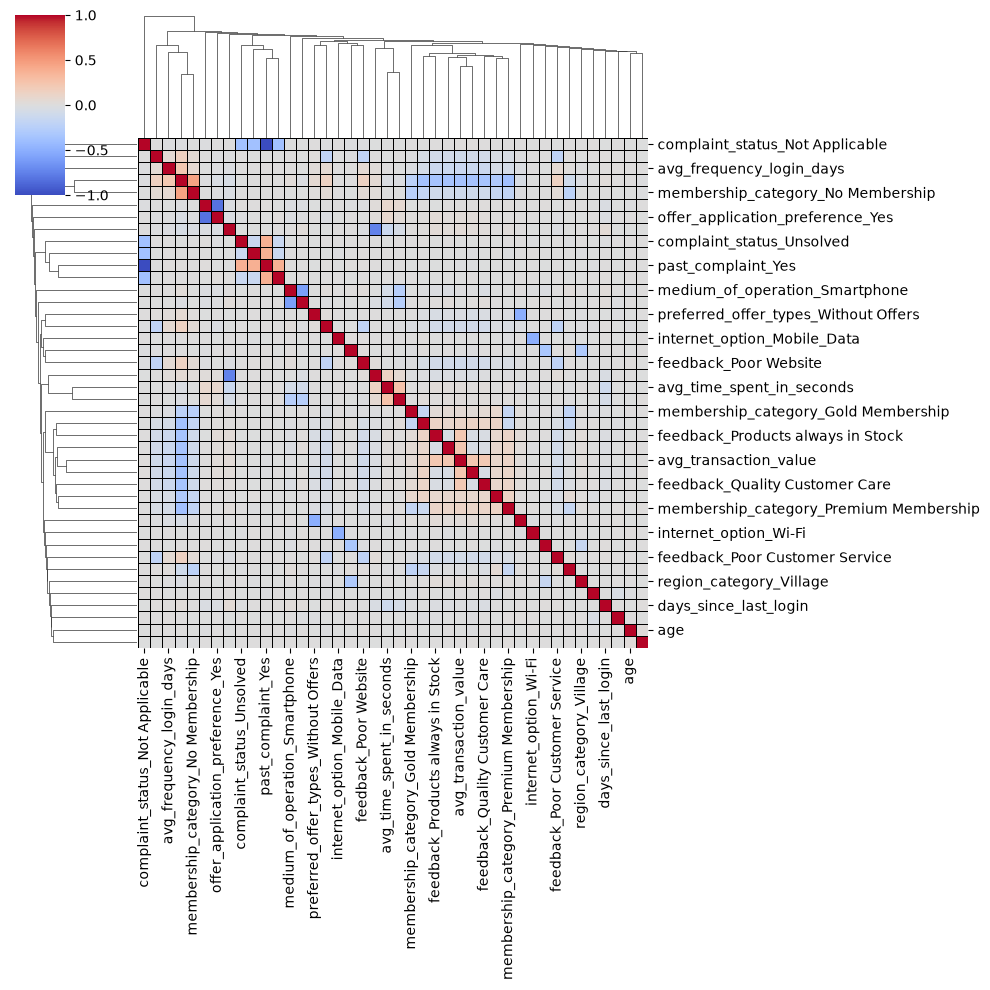

In [578]:
sns.clustermap(corr_matrix, cmap='coolwarm', linewidths=0.5, linecolor='black')

In [579]:
upper_tri = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

# 3. Find features with correlation higher than the threshold (e.g., 0.95)
threshold = 0.9
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]

# 4. Drop the highly correlated columns
data_train = data_train.drop(columns=to_drop)
data_test = data_test.drop(columns=to_drop)

print(to_drop)

['complaint_status_Not Applicable']


### Feature Selection (Filtering)

In [580]:
correlations=data_train.corrwith(label_train).abs()
correlations=correlations.to_list()

for i in range(len(correlations)):
    if correlations[i]<=0.1:
        print(i)   # Not implemented as of now

0
1
2
7
8
9
10
11
12
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


### Standardization

In [581]:
feature_cols = [c for c in data_train.columns if c != 'churn_risk_score']

In [582]:
scaler=StandardScaler()
data_train_scaled = scaler.fit_transform(data_train[feature_cols])
data_test_scaled  = scaler.transform(data_test[feature_cols])

joblib.dump(scaler,TRAINED_MODELS_PATH/'standard_scaler.joblib')

data_train = pd.DataFrame(data_train_scaled, columns=feature_cols, index=data_train.index)
data_test  = pd.DataFrame(data_test_scaled,  columns=feature_cols, index=data_test.index)

assert data_train.index.equals(label_train.index)
assert data_test.index.equals(label_test.index)

data_train = data_train.reset_index(drop=True)
label_train = label_train.reset_index(drop=True)
data_test = data_test.reset_index(drop=True)
label_test = label_test.reset_index(drop=True)

In [583]:
label_train=label_train-1
label_test=label_test-1

In [584]:
data_train.to_csv(path_or_buf=PATH_TRAIN_PARSED, index=False)
data_test.to_csv(path_or_buf=PATH_TEST_PARSED, index=False)
label_train.to_csv(path_or_buf=PATH_TRAIN_LABEL_PARSED, index=False)
label_test.to_csv(path_or_buf=PATH_TEST_LABEL_PARSED, index=False)